In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

In [2]:
plt.style.use('seaborn-v0_8')
sn.set_palette('husl')
print("All libraries loaded successfully")

All libraries loaded successfully


In [3]:
df = pd.read_excel("Cleaned_Data_Project.xlsx")

In [4]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (1200, 14)
Columns: ['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']


In [5]:
total_revenue = df['TotalPrice'].sum()
total_orders = df['OrderID'].count()
avg_order_value = df['TotalPrice'].mean()

In [6]:
print("===SALES & REVENUE SUMMARY ===")
print(f" Total Revenue: ${total_revenue:,.2f}")
print(f" Total_Orders: {total_orders}")
print(f" Average Order Value: ${avg_order_value:,.2f}")

===SALES & REVENUE SUMMARY ===
 Total Revenue: $1,264,761.96
 Total_Orders: 1200
 Average Order Value: $1,053.97


In [7]:
df['Month'] = pd.to_datetime(df['Date']).dt.strftime('%b')
df['MonthNum'] = pd.to_datetime(df['Date']).dt.month
monthly_revenue = df.groupby(['MonthNum', 'Month'])['TotalPrice'].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values('MonthNum')

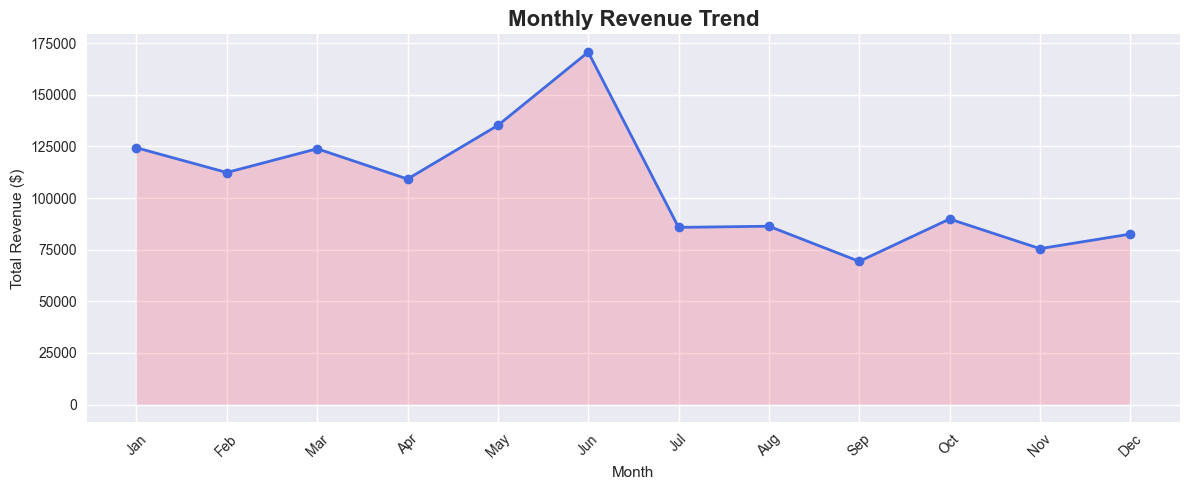

Monthly Revenue Chart displayed!


In [8]:
plt.figure(figsize=(12,5))
plt.plot(monthly_revenue['Month'], monthly_revenue['TotalPrice'], marker='o', linewidth=2, color='royalblue')
plt.fill_between(monthly_revenue['Month'], monthly_revenue['TotalPrice'], alpha=0.3)
plt.title('Monthly Revenue Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Monthly Revenue Chart displayed!")

In [9]:
product_analysis = df.groupby('Product').agg(
    Total_Revenue = ('TotalPrice', 'sum'),
    Total_Orders = ('OrderID', 'count'),
    Total_Quantity = ('Quantity', 'sum'),
    Avg_Order_Value = ('TotalPrice', 'mean')
).reset_index()

product_analysis = product_analysis.sort_values('Total_Revenue', ascending=False)
print("=== PRODUCT PERFORMANCE SUMMARY ===")
print(product_analysis.to_string(index=False))

=== PRODUCT PERFORMANCE SUMMARY ===
Product  Total_Revenue  Total_Orders  Total_Quantity  Avg_Order_Value
  Chair      195620.11           178             562      1098.989382
Printer      195612.61           181             542      1080.732652
 Laptop      192126.56           173             535      1110.558150
 Tablet      186568.95           179             497      1042.284637
Monitor      175651.41           163             480      1077.616012
   Desk      167459.93           170             508       985.058412
  Phone      151722.39           156             411       972.579423


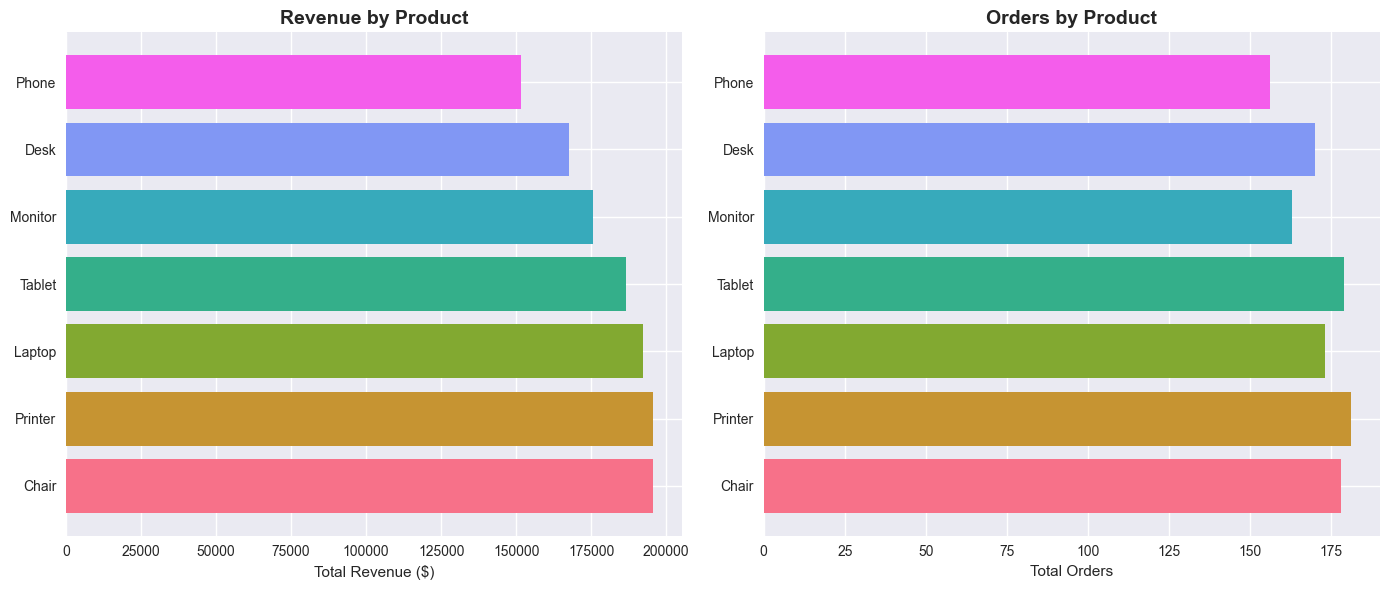

Product Performance Charts displayed!


In [10]:
fig, (ax1,ax2) = plt.subplots(1, 2, figsize = (14, 6))
ax1.barh(product_analysis['Product'],
         product_analysis['Total_Revenue'],
         color = sn.color_palette("husl", len(product_analysis)))
ax1.set_title('Revenue by Product', fontsize=14, fontweight='bold')
ax1.set_xlabel('Total Revenue ($)')
ax2.barh(product_analysis['Product'],
         product_analysis['Total_Orders'],
         color = sn.color_palette("husl", len(product_analysis)))
ax2.set_title('Orders by Product', fontsize=14, fontweight='bold')
ax2.set_xlabel('Total Orders')
plt.tight_layout()
plt.show()
print("Product Performance Charts displayed!")


In [11]:
payment_analysis = df.groupby('PaymentMethod').agg(
    Total_Orders = ('OrderID', 'count'),
    Total_Revenue = ('TotalPrice', 'sum'),
    Avg_Order_Value = ('TotalPrice', 'mean')
).reset_index()

payment_analysis = payment_analysis.sort_values('Total_Orders', ascending = False)
print("===PAYMENT METHOD SUMMARY===")
print(payment_analysis.to_string(index=False))


===PAYMENT METHOD SUMMARY===
PaymentMethod  Total_Orders  Total_Revenue  Avg_Order_Value
       Online           258      262442.94      1017.220698
         Cash           246      259786.29      1056.041829
  Credit Card           234      263847.63      1127.553974
   Debit Card           232      232361.18      1001.556810
    Gift Card           230      246323.92      1070.973565


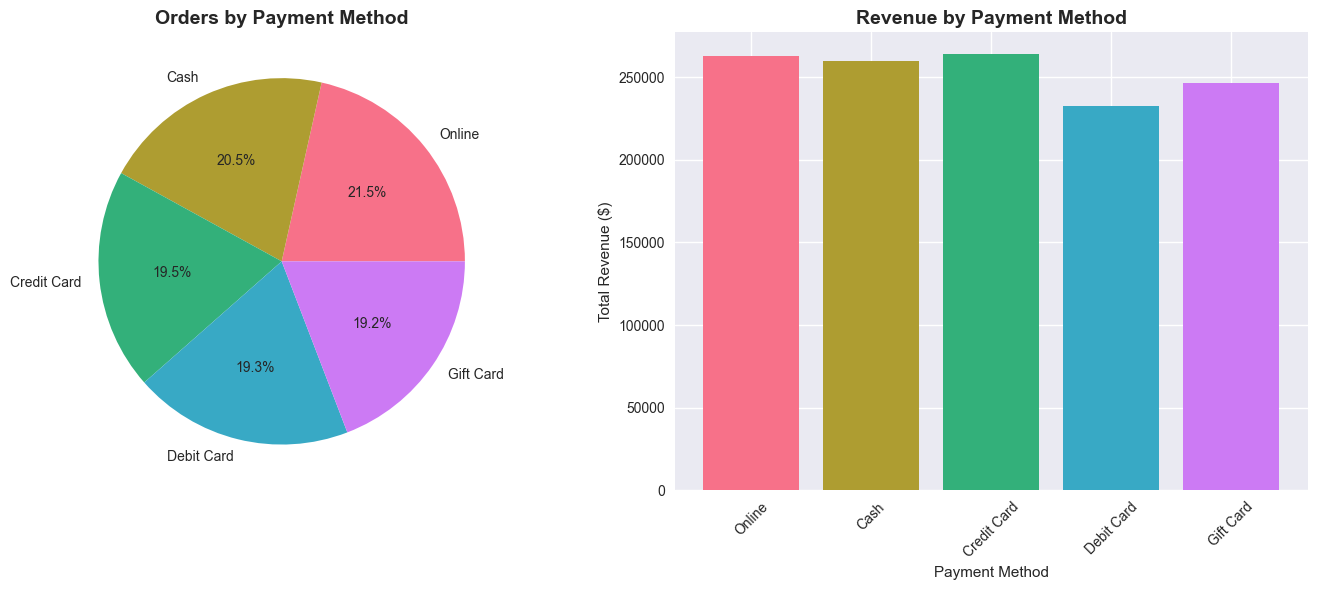

Payment Method Charts displayed!


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.pie(payment_analysis['Total_Orders'],
        labels=payment_analysis['PaymentMethod'],
        autopct='%1.1f%%',
        colors=sn.color_palette("husl", len(payment_analysis)))
ax1.set_title('Orders by Payment Method', fontsize=14, fontweight='bold')

ax2.bar(payment_analysis['PaymentMethod'],
        payment_analysis['Total_Revenue'],
        color=sn.color_palette("husl", len(payment_analysis)))
ax2.set_title('Revenue by Payment Method', fontsize=14, fontweight='bold')
ax2.set_xlabel('Payment Method')
ax2.set_ylabel('Total Revenue ($)',)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Payment Method Charts displayed!")

                            

In [13]:
customer_analysis = df.groupby('CustomerID').agg(
    Total_Revenue = ('TotalPrice', 'sum'),
    Total_Orders = ('OrderID', 'count'),
    Avg_Order_Value = ('TotalPrice', 'mean')
).reset_index()

customer_analysis = customer_analysis.sort_values('Total_Revenue', ascending=False)
top10_customers = customer_analysis.head(10)

print("=== TOP 10 CUSTOMERS BY REVENUE ===")
print(top10_customers.to_string(index=False))

=== TOP 10 CUSTOMERS BY REVENUE ===
CustomerID  Total_Revenue  Total_Orders  Avg_Order_Value
    C38840        5723.23             2         2861.615
    C57276        3456.40             1         3456.400
    C67260        3390.80             1         3390.800
    C13877        3384.90             1         3384.900
    C18404        3370.20             1         3370.200
    C16775        3353.75             1         3353.750
    C65986        3352.40             1         3352.400
    C47778        3334.00             1         3334.000
    C59183        3322.55             1         3322.550
    C25276        3313.90             1         3313.900


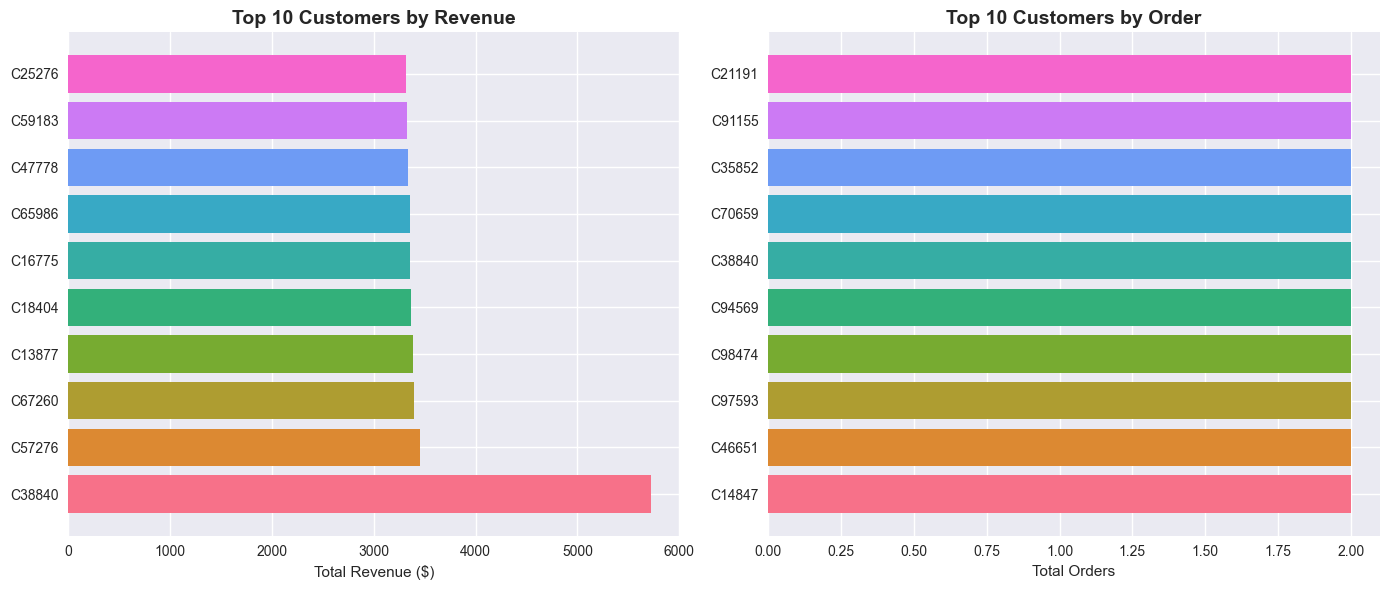

Customer Analysis Charts displayed!


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 6))

ax1.barh(top10_customers['CustomerID'],
         top10_customers['Total_Revenue'],
         color = sn.color_palette("husl", 10))
ax1.set_title('Top 10 Customers by Revenue', fontsize=14, fontweight='bold')
ax1.set_xlabel('Total Revenue ($)')

top10_orders = customer_analysis.sort_values('Total_Orders', ascending=False).head(10)
ax2.barh(top10_orders['CustomerID'],
         top10_orders['Total_Orders'],
         color = sn.color_palette("husl", 10))
ax2.set_title('Top 10 Customers by Order', fontsize=14, fontweight='bold')
ax2.set_xlabel('Total Orders')

plt.tight_layout()
plt.show()

print("Customer Analysis Charts displayed!")
                        

In [15]:
df['Month'] = pd.to_datetime(df['Date']).dt.strftime('%b')
df['MonthNum'] = pd.to_datetime(df['Date']).dt.month

monthly_trends = df.groupby(['MonthNum', 'Month']).agg(
    Total_Revenue = ('TotalPrice', 'sum'),
    Total_Orders = ('OrderID', 'count'),
    Total_Quantity = ('Quantity', 'sum')
).reset_index()

monthly_trends = monthly_trends.sort_values('MonthNum')

print("=== MONTHLY TRENDS SUMMARY ===")
print(monthly_trends[['Month', 'Total_Revenue', 'Total_Orders', 'Total_Quantity']].to_string(index=False))

=== MONTHLY TRENDS SUMMARY ===
Month  Total_Revenue  Total_Orders  Total_Quantity
  Jan      124313.23           106             328
  Feb      112344.78           106             303
  Mar      123840.93           128             367
  Apr      109186.05           113             320
  May      135142.59           120             356
  Jun      170616.13           147             458
  Jul       85784.64            87             243
  Aug       86343.21            79             260
  Sep       69321.65            73             208
  Oct       89834.82            78             241
  Nov       75493.43            76             211
  Dec       82540.50            87             240


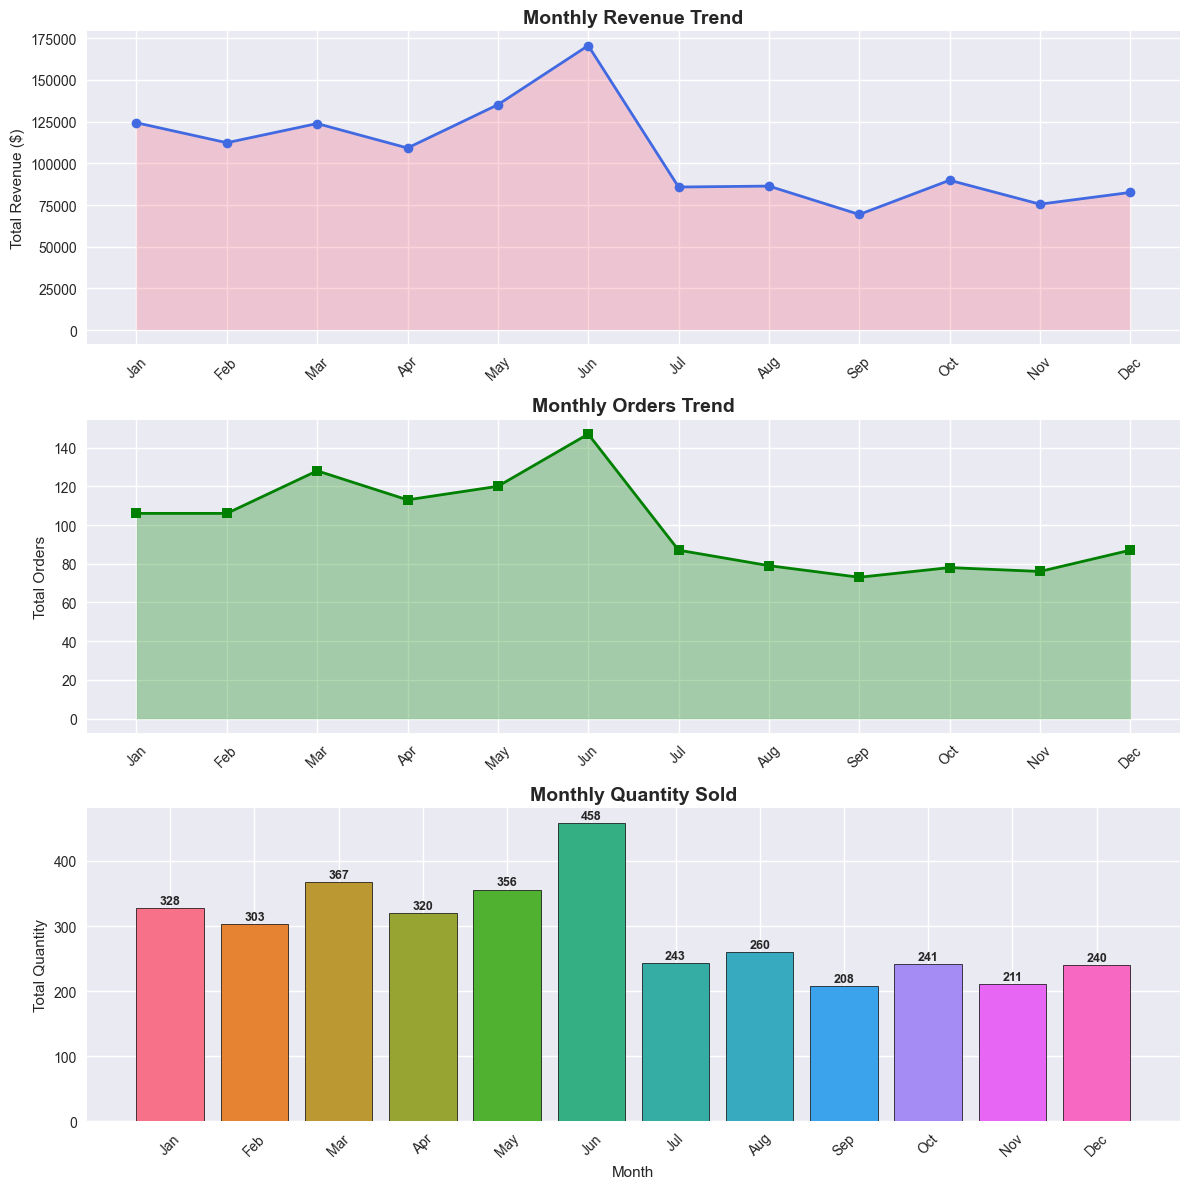

Monthly Trends Charts displayed!


In [16]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12))

ax1.plot(monthly_trends['Month'],
         monthly_trends['Total_Revenue'],
         marker = 'o', linewidth = 2, color = 'royalblue')
ax1.fill_between(monthly_trends['Month'],
                 monthly_trends['Total_Revenue'], alpha = 0.3)
ax1.set_title('Monthly Revenue Trend', fontsize = 14, fontweight = 'bold')
ax1.set_ylabel('Total Revenue ($)')
ax1.tick_params(axis='x', rotation=45)

ax2.plot(monthly_trends['Month'],
         monthly_trends['Total_Orders'],
         marker = 's', linewidth = 2, color = 'green')
ax2.fill_between(monthly_trends['Month'],
                 monthly_trends['Total_Orders'], alpha = 0.3, color = 'green')
ax2.set_title('Monthly Orders Trend', fontsize = 14, fontweight = 'bold')
ax2.set_ylabel('Total Orders')
ax2.tick_params(axis = 'x', rotation = 45)

ax3.bar(monthly_trends['Month'],
                 monthly_trends['Total_Quantity'],
                 color = sn.color_palette("husl", len(monthly_trends)),
                    edgecolor = 'black',
                    linewidth = 0.5)
for i, (month, qty) in enumerate(zip(monthly_trends['Month'],
                                     monthly_trends['Total_Quantity'])):
    ax3.text(i, qty + 2, str(qty),
             ha='center', va='bottom',
             fontweight='bold', fontsize=9)
    
ax3.set_title('Monthly Quantity Sold', fontsize = 14, fontweight = 'bold')
ax3.set_xlabel('Month')
ax3.set_ylabel('Total Quantity')
ax3.tick_params(axis = 'x', rotation = 45)

plt.tight_layout()
plt.show()

print("Monthly Trends Charts displayed!")

In [17]:
print("Quantity column type:", df['Quantity'].dtype)
print("Sample Quantity values:", df['Quantity'].head(10).tolist())
print("Monthly trends sample:")
print(monthly_trends[['Month', 'Total_Quantity']].to_string(index=False))


Quantity column type: int64
Sample Quantity values: [1, 2, 1, 3, 2, 2, 2, 5, 5, 5]
Monthly trends sample:
Month  Total_Quantity
  Jan             328
  Feb             303
  Mar             367
  Apr             320
  May             356
  Jun             458
  Jul             243
  Aug             260
  Sep             208
  Oct             241
  Nov             211
  Dec             240


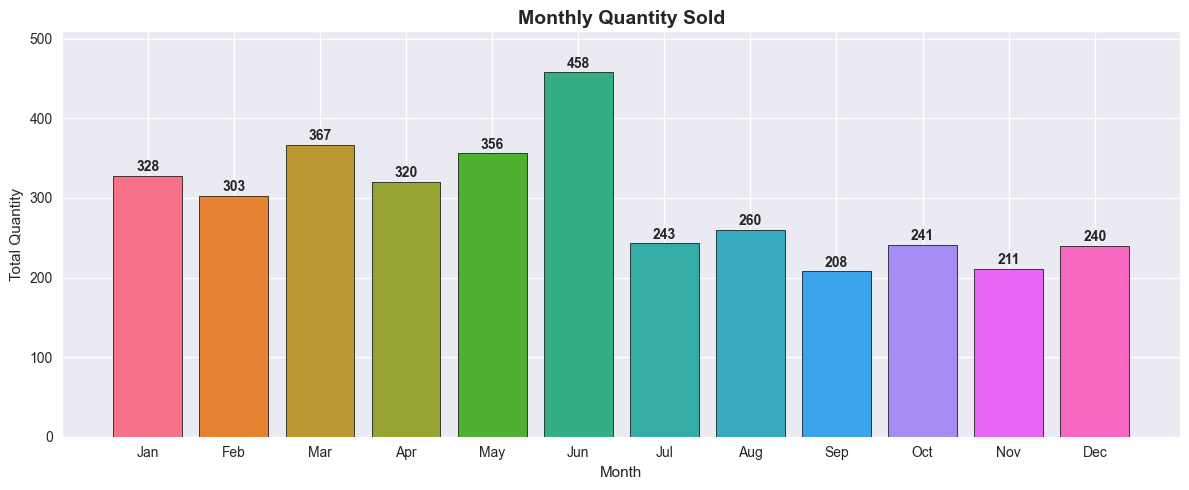

Monthly Quantity Chart displayed!


In [18]:
months = monthly_trends['Month'].tolist()
quantities = monthly_trends['Total_Quantity'].tolist()

plt.figure(figsize=(12, 5))
bars = plt.bar(months, quantities,
               color = sn.color_palette("husl", 12),
               edgecolor = 'black',
               linewidth = 0.5)

for bar, qty in zip(bars, quantities):
    plt.text(bar.get_x() + bar.get_width()/2.,
             bar.get_height() + 2,
             str(qty),
             ha='center', va='bottom',
             fontweight = 'bold', fontsize = 10)
plt.title('Monthly Quantity Sold', fontsize = 14, fontweight = 'bold')
plt.xlabel('Month')
plt.ylabel('Total Quantity')
plt.ylim(0, max(quantities) + 50)
plt.tight_layout()
plt.show()

print("Monthly Quantity Chart displayed!")
                                            

In [19]:
print("Mean TotalPrice:", df['TotalPrice'].mean().round(2))
print("Median TotalPrice:", df['TotalPrice'].median().round(2))
print("Mean Quantity:", df['Quantity'].mean().round(2))
print("Median Quantity:", df['Quantity'].median().round(2))

Mean TotalPrice: 1053.97
Median TotalPrice: 823.62
Mean Quantity: 2.95
Median Quantity: 3.0


In [20]:
prices = df['TotalPrice'].values.tolist()

In [21]:
print("===DESCRIPTIVE STATISTICS ===")
print(f"Mean: ${sum(prices)/len(prices):,.2f}")
print(f"Median: ${sorted(prices)[len(prices)//2]:,.2f}")
print(f"Min: ${min(prices):,.2f}")
print(f"Max: ${max(prices):,.2f}")


===DESCRIPTIVE STATISTICS ===
Mean: $1,053.97
Median: $824.25
Min: $11.39
Max: $3,456.40


In [22]:
prices_array = np.array(prices)
q1 = np.percentile(prices_array, 25)
q3 = np.percentile(prices_array, 75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print("\n=== OUTLIER ANALYSIS ===")
print(f"Lower Boundary: ${lower:,.2f}")
print(f"Upper Boundary: ${upper:,.2f}")

outlier_mask = (prices_array < lower) | (prices_array > upper)
print(f"Total Outliers Found: {outlier_mask.sum()}")


=== OUTLIER ANALYSIS ===
Lower Boundary: $-1,341.41
Upper Boundary: $3,330.41
Total Outliers Found: 8


In [23]:
outlier_rows = df[(df['TotalPrice'] < lower) |
    (df['TotalPrice'] > upper)]
print("=== 8 OUTLIER ORDERS ===")
print(outlier_rows[['OrderID', 'Product', 'Quantity', 'UnitPrice', 'TotalPrice']].to_string(index=False))

=== 8 OUTLIER ORDERS ===
  OrderID Product  Quantity  UnitPrice  TotalPrice
ORD200328  Tablet         5     674.04     3370.20
ORD200107 Printer         5     670.75     3353.75
ORD200632  Laptop         5     678.16     3390.80
ORD201122 Monitor         5     678.19     3390.95
ORD200789  Tablet         5     691.28     3456.40
ORD201065 Printer         5     666.80     3334.00
ORD200469   Chair         5     676.98     3384.90
ORD200326  Laptop         5     670.48     3352.40
